In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("Downloads/clean_transactions_pandas.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
df.head()

Shape: (469409, 32)

Columns:
 Index(['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en',
       'procedure_name_en', 'instance_date', 'property_type_id',
       'property_type_en', 'property_sub_type_id', 'property_sub_type_en',
       'property_usage_en', 'reg_type_id', 'reg_type_en', 'area_id',
       'area_name_en', 'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3'],
      dtype='object')


,transaction_id,procedure_id,trans_group_id,trans_group_en,procedure_name_en,instance_date,property_type_id,property_type_en,property_sub_type_id,property_sub_type_en,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,3-9-2006-163,9,3,Gifts,Grant,2006-10-16,4,Villa,NaN,NaN,...,NaN,0,3162.42,12000000.0,3794.56,NaN,NaN,3.0,1.0,0.0
1,3-9-2019-2944,9,3,Gifts,Grant,2019-11-13,1,Land,NaN,NaN,...,NaN,0,209.09,916659.0,4384.04,NaN,NaN,2.0,4.0,0.0
2,2-13-2001-690,13,2,Mortgages,Mortgage Registration,2001-08-20,2,Building,NaN,NaN,...,NaN,0,1337.80,4519342.0,3378.19,NaN,NaN,1.0,1.0,0.0
3,2-13-2020-9477,13,2,Mortgages,Mortgage Registration,2020-11-30,2,Building,NaN,NaN,...,NaN,0,278.71,2500000.0,8969.90,NaN,NaN,1.0,1.0,0.0
4,2-13-1999-532,13,2,Mortgages,Mortgage Registration,1999-04-26,4,Villa,NaN,NaN,...,NaN,0,3626.93,1900000.0,523.86,NaN,NaN,1.0,1.0,0.0


In [2]:
# Keep only Sales transactions
df_sales = df[df["trans_group_en"] == "Sales"].copy()

print("Sales shape:", df_sales.shape)
df_sales[["trans_group_en", "actual_worth"]].head()

Sales shape: (359066, 32)


,trans_group_en,actual_worth
5,Sales,7000000.0
9,Sales,5000000.0
13,Sales,1000000.0
14,Sales,73500000.0
16,Sales,1500000.0


In [3]:
# Remove missing values
df_sales = df_sales[df_sales["actual_worth"].notna()]

# Remove zero or negative prices
df_sales = df_sales[df_sales["actual_worth"] > 0]

print("Cleaned sales shape:", df_sales.shape)

# Check distribution
print(df_sales["actual_worth"].describe())

Cleaned sales shape: (359066, 32)
count    3.590660e+05
mean     2.729945e+06
std      1.285680e+07
min      1.000000e+00
25%      7.500000e+05
50%      1.350000e+06
75%      2.500000e+06
max      3.579358e+09
Name: actual_worth, dtype: float64


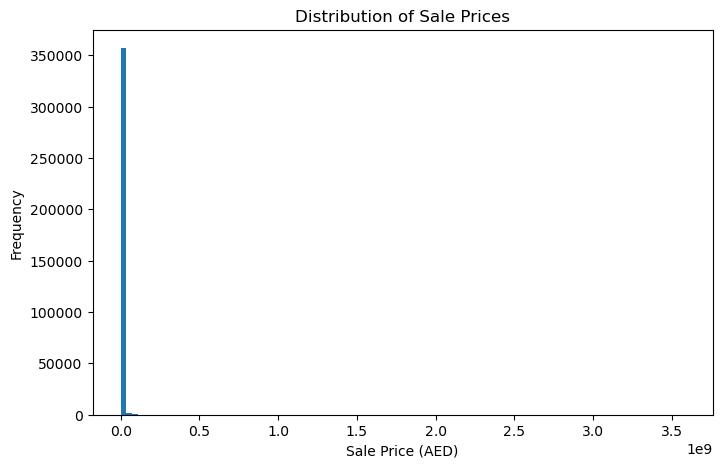

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df_sales["actual_worth"], bins=100)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price (AED)")
plt.ylabel("Frequency")
plt.show()

In [5]:
print("Skewness:", df_sales["actual_worth"].skew())

Skewness: 105.26502745055744


In [6]:
df_sales["log_price"] = np.log(df_sales["actual_worth"])

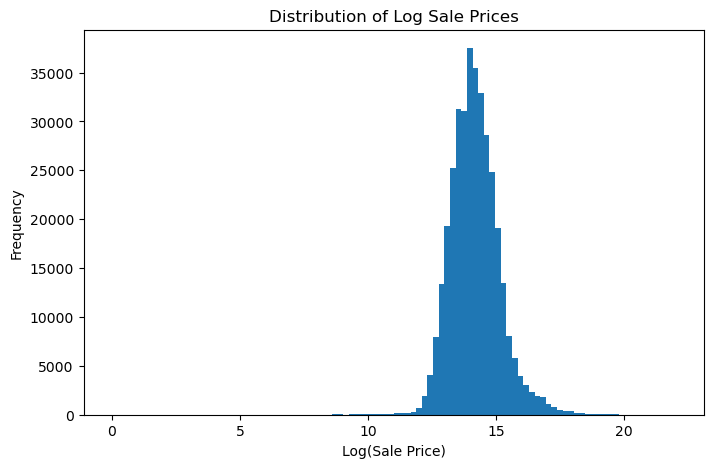

New skewness: 0.46451971638240214


In [7]:
plt.figure(figsize=(8,5))
plt.hist(df_sales["log_price"], bins=100)
plt.title("Distribution of Log Sale Prices")
plt.xlabel("Log(Sale Price)")
plt.ylabel("Frequency")
plt.show()

print("New skewness:", df_sales["log_price"].skew())

In [8]:
features = [
    "procedure_area",
    "property_type_en",
    "property_usage_en",
    "area_name_en",
    "rooms_en",
    "has_parking"
]

df_model = df_sales[features + ["log_price"]].copy()

print(df_model.shape)
df_model.head()

(359066, 7)


,procedure_area,property_type_en,property_usage_en,area_name_en,rooms_en,has_parking,log_price
5,211.37,Building,Residential,Al Karama,NaN,0,15.761421
9,211.35,Building,Residential,Al Karama,NaN,0,15.424948
13,272.21,Building,Residential,Al Raffa,NaN,0,13.815511
14,5171.22,Building,Residential / Commercial,Al Hamriya,NaN,0,18.112796
16,232.26,Villa,Residential,Al Satwa,NaN,0,14.220976


In [9]:
print(df_model.isnull().sum())

procedure_area           0
property_type_en         0
property_usage_en        0
area_name_en             0
rooms_en             60727
has_parking              0
log_price                0
dtype: int64


In [10]:
print(df_model["rooms_en"].unique())

[nan '2 B/R' '4 B/R' '3 B/R' 'Office' '1 B/R' 'Studio' 'Shop' '5 B/R'
 'Store' 'PENTHOUSE' '6 B/R' 'Single Room' '7 B/R' 'GYM' '9 B/R']


In [11]:
df_model = df_model.drop(columns=["rooms_en"])

print(df_model.isnull().sum())
print(df_model.shape)

procedure_area       0
property_type_en     0
property_usage_en    0
area_name_en         0
has_parking          0
log_price            0
dtype: int64
(359066, 6)


In [12]:
X = df_model.drop(columns=["log_price"])
y = df_model["log_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (359066, 5)
y shape: (359066,)


In [13]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (359066, 5)
Encoded X shape: (359066, 241)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (287252, 241)
Testing shape: (71814, 241)


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.4807149997686838
MSE: 0.45666464833626846
RMSE: 0.6757696710686774
R2 Score: 0.5022293604416694


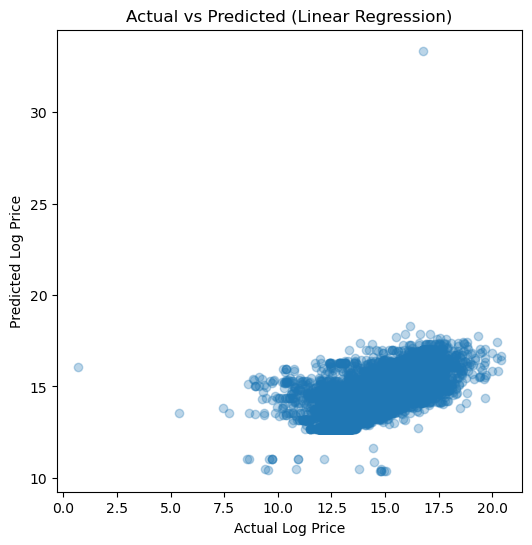

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

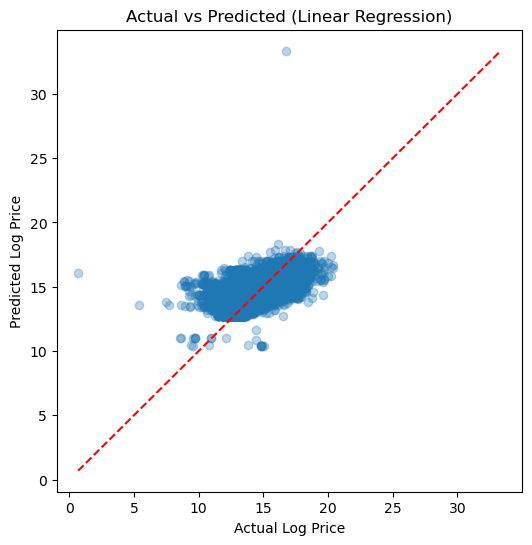

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

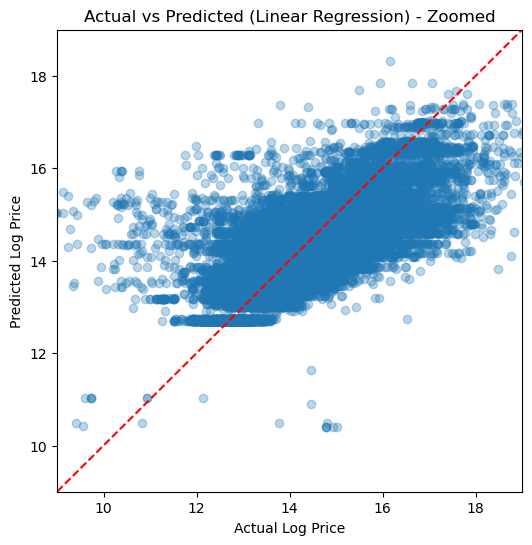

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlim(9, 19)
plt.ylim(9, 19)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted (Linear Regression) - Zoomed")
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Fit model
rf_model.fit(X_train, y_train)

print("Random Forest model training complete.")

Random Forest model training complete.


In [22]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results:
MAE: 0.2497967606726926
MSE: 0.1856427366627734
RMSE: 0.4308627817098773
R2 Score: 0.7976469076495221


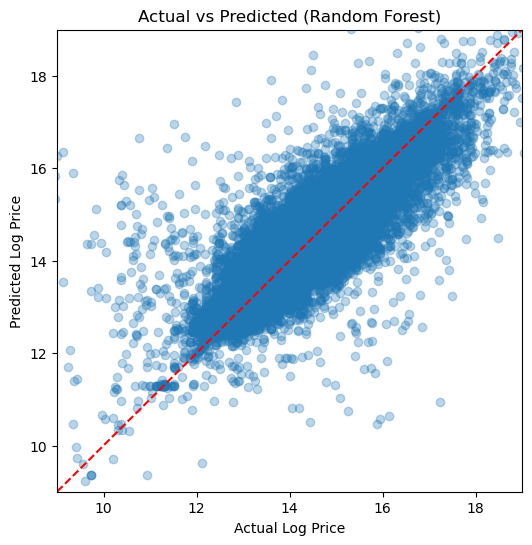

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlim(9, 19)
plt.ylim(9, 19)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

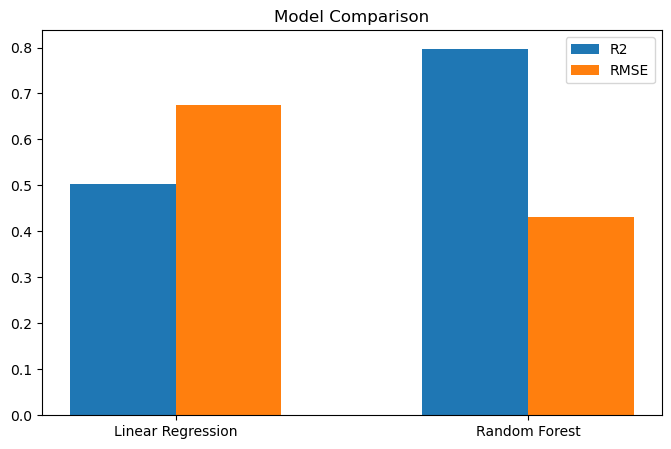

In [26]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Linear Regression', 'Random Forest']
r2_scores = [r2, r2_rf]
rmse_scores = [rmse, rmse_rf]

x = np.arange(len(models))

plt.figure(figsize=(8,5))
plt.bar(x - 0.15, r2_scores, width=0.3, label='R2')
plt.bar(x + 0.15, rmse_scores, width=0.3, label='RMSE')

plt.xticks(x, models)
plt.title("Model Comparison")
plt.legend()
plt.show()

In [ ]:
# R2 shows how well the model explains price variation,
# while RMSE shows how large the prediction errors are.